<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Relatividad-y-gravitacion/PS12_AgujerosNegros_RG_2024_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Relatividad y Gravitación</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Problem Set 12</center></b><h2>
<h3><b><center>Agujeros negros de Schwarzschild</center></b><h3>
<h5><center><b>Asignada</b>: Domingo 16 de febrero de 2025</center><h5>
<h5><center><b>Entrega</b>: Domingo 23 de febrero de 2025</center><h5>
<small><center><i>Última actualización del profesor</i>: Domingo 16 de febrero de 2025, 10:00</center></small>

**NOTA**: Al inicio de la solución entregada debe incluir una relación de los puntos y los literales que resolvió completamente.

> *completo totalmente*

___

A continuación se presentan un conjunto de ejercicios o problemas para resolver usando la teoría vista en las últimas lecciones del curso. Resuelva los ejercicios *a mano* y suba una versión digitalizada en el espacio del ítem respectivo en Google Classroom.

**NOTA**: Los ejercicios marcados como **[Numérico]** deben resolverse exclusivamente usando las herramientas numéricas vistas en el curso, incluso si tienen una solución que puede obtenerse de forma enteramente analítica. El objetivo es que se aprendan a utilizar esas herramientas.

1. **Geodésicas nulas radiales en la métrica de Schwarzschild**. Vamos a estudiar analítica y numéricamente las geodésicas nulas (trayectorias de la luz) en dirección radial en la métrica de Schwarzschild. Para ello:

   1. Demuestre que la ecuación de una geodésica radial está dada por:
   
   $$
   \frac{\mathrm{d} t}{\mathrm{~d} r}= \pm \frac{1}{c} \frac{1}{1-R_{\mathrm{S}} / r}
   $$

   2. Si un rayo de luz es emitido en $t=t_0,r=r_0$ y detectado en $t,r$, muestre que la coordenada de Shcwarzschild temporal en el evento de detección es:

   $$
   t-t_{0}=\frac{r-r_0}{c}+\frac{R_{\mathrm{S}}}{c} \ln \left(\frac{r-R_{\mathrm{S}}}{r_0-R_{\mathrm{S}}}\right)
   $$

   3. Escriba un código interactivo para, fijado un valor de $r$ y $t_0=0$, y variando $r_0$, se pueda ilustrar como es la geodésica nula en el espacio-tiempo (eje horizontal el tiempo, eje vertical la coordenada radial). En el mismo gráfico ponga siempre como comparación la geodésica nula que recorrería el rayo de luz si se moviera en espacio-tiempo globalmente plano (Minkowski). Ponga las escalas del dibujo en unidades de $R_S$.

   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

El parametro de variacion $r_0$ es el **radio desde donde se emite la luz** hacia afuera del cuerpo. Para evitar la singularidad en el radio de schwarzschild $R_s$ este punto y las coordenadas radiales se fijaron para variar por encima de $R_s$. Con esto se grafico la coordenada temporal de Shcwarzschild de 2.2 y para la de minkowski, que es el caso plano, la solucion es una linea recta.

In [ ]:
# parametros y ctes
c = 1 # vel luz
t0 = 0 # tiempo de emision
R_s = 1 # radio de schwarzchild


@interact(r0=(1.01*R_s, 15*R_s, 0.1), continuous_update=False)
def interactua(r0=1.01*R_s): # variando el radio de emision luz

  r = np.linspace(r0, 20*R_s, 1000) # coordenada radial

  # coordenada temporal
  t_schw = t0 + (r-r0)/c + (R_s/c)*np.log((r - R_s)/(r0 - R_s)) # schwarzhild
  t_mink = t0 + (r-r0)/c # minkowski

  # grafica
  plt.title('Relacion Radio-Tiempo de geodesica nula')
  plt.plot(t_schw, r, label='Metrica Schwarzschild')
  plt.plot(t_mink, r, label='Metrica Minkowski')
  plt.plot([0],[r0], 'yo', label='punto de emision')
  plt.axhline(y=R_s, color='k', label='Radio Schwarzschild')
  plt.xlabel('t [unidades luz]')
  plt.ylabel('r [$R_s$]')
  plt.legend()
  plt.grid()
  plt.show()

interactive(children=(FloatSlider(value=1.01, description='r0', max=15.0, min=1.01), Output()), _dom_classes=(…

2. **El corrimiento espectral de la estrella S0-2**. Alrededor del agujero negro central de la Vía Láctea hay un cúmulo estelar, en el cuál la estrella más importante es, en términos de la información que hemos obtenido sobre el agujero negro, la estrella S0-2.

  La órbita de la estrella, de acuerdo a [esta fuente](https://arxiv.org/pdf/1807.09409), tiene $a=125.38\pm 0.18$ mas, $P=16.0525$ años y $e=0.88473\pm 0.00018$ y se encuentra ubicada a una distancia de nosotros de 8122 pc. Para las estimaciones que usaremos aquí asumiremos que la órbita es observada *face-on* (desde arriba).
  
  Usando estos datos:

   1. Calcule la masa del agujero negro en Sagitario A*. Usando este dato y asumiendo que el movimiento es Kepleriano, muestre que la velocidad de la estrella en un punto de coordenada radial $r$ es:
     
     $$
     \beta^2\simeq \frac{R_s}{r} - \frac{R_s}{2 a}
     $$
     donde $\beta=V/c$ y $V$ es la rapidez orbital medida por un observador en reposo en el punto $r$ (el $\simeq$ es porque asumimos movimiento Kepleriano aunque en realidad no lo es porque estamos en relatividad general).
     ¿Cuál es el valor máximo de $\beta$ que puede tener la estrella S0-2?.
     
   2. El corrimiento espectral observado para la estrella, en la configuración asumida (órbita face-on) se produce por 2 efectos: 1) corrimiento gravitacional debido a los efectos de la métrica de Schwarzschild, y 2) el corrimiento Doppler-transversal que es producido por el fenómeno de aberración de la luz.
   
     Demostrar que a segundo orden en $\beta$ el corrimiento espectral total es:

     $$
     z = B_{0G} + (B_{2G} + B_{2T})\beta^2
     $$
     donde $B_{0G}=R_S/(2r)$ y $B_{2G} = B_{2T} = 1/2$.

   3. Grafique el corrimiento espectral esperado para la estrella como función del tiempo por una órbita completa. Compare el resultado que se obtendría si se asumiera que el espacio-tiempo es plano y que el único efecto observado es el efecto Doppler relativista transversal.

  Otra referencia de interés sobre este tema se encuentra en [este enlace](https://iopscience.iop.org/article/10.1086/501436/pdf).


In [ ]:
from astropy import units as u
from astropy import constants as ac
from scipy.optimize import fsolve

definiendo constantes y parametros importantes

In [ ]:
# contantes
G = ac.G.value          # cte gravitacion [m^3/kg s^2]
c = ac.c.value          # velocidad luz [m/s]
M_sun = ac.M_sun.value  # masa solar [kg]
pc = ac.pc.value        # [m]
yr = 1*u.year           # 1 [año]
s = 1*u.second          # 1 [segundo]
au = ac.au.value        # unidad astronomica [m]
mas_to_rad = np.pi/(1000*180*60*60) # mas a radianes

# Parametros de la orbita de S02
P = (16.0525*yr).to(s)      # periodo [s]
e = 0.88473                 # excentricidad
d = 8122*pc                 # distancia [m]
a_mas = 125.38              # semieje-mayor [mas]
a = a_mas * mas_to_rad * d  # semieje-mayor [m]

# Parametros del agujero negro
M = 4.1e6 * M_sun           # masa [kg]
Rs = 2*G*M/ c**2            # radio Schwarzschild [m]

encontrando el valor de z para cada tiempo en la orbita

In [ ]:
# Tiempo en una orbita completa
t_vals = np.linspace(0, P, 500)
n = 2*np.pi / P  # frecuencia media


# coeficientes de la expansion en beta
B0G = Rs / (4*a)  # orden 0 gravitacional
B2G = B2T = 1/2   # orden 2 gravitacional y doppler

# Para encontrar el valor de beta en la orbita:

# Ecuación de Kepler para encontrar E(t)
def kepler(E, M, e):
  return E - e * np.sin(E) - M

rs = []
z_total = []
z_doppler = []

for t in t_vals:
  """ fragmento de codigo para encontrar radio orbital-Recuperado de deep seek """
  M_t = n * t  # Anomalia media
  E_t = fsolve(kepler, M_t, args=(M_t, e))[0]  # anomalia excentrica
  theta_t = 2*np.arctan( np.sqrt((1+e)/(1-e))*np.tan(E_t/2) )  # Anomalia verdadera
  r_t = a*(1 - e**2)/(1 + e*np.cos(theta_t))  # Radio orbital

  beta_2 = (Rs/r_t) - (Rs/(2*a))  # beta^2

  # guardando datos
  rs.append( r_t )
  z_total.append( B0G + (B2G + B2T)*beta_2 )
  z_doppler.append( B2T*beta_2 )

graficando z en funcion del tiempo de orbita y radio orbital

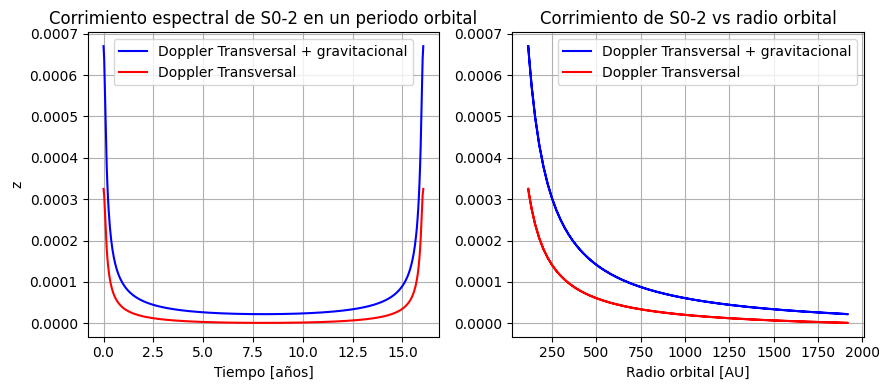

In [ ]:
# Graficar
fig, [ax1,ax2] = plt.subplots(1,2, figsize=(9, 4))

ax1.plot(t_vals.to(yr), z_total, label='Doppler Transversal + gravitacional', color='b')
ax1.set_title('Corrimiento espectral de S0-2 en un periodo orbital')
ax1.plot(t_vals.to(yr), z_doppler, label='Doppler Transversal', color='r')
ax1.set_xlabel('Tiempo [años]')
ax1.set_ylabel('z')

ax2.plot(rs/au, z_total, label='Doppler Transversal + gravitacional', color='b')
ax2.plot(rs/au, z_doppler, label='Doppler Transversal', color='r')
ax2.set_title('Corrimiento de S0-2 vs radio orbital')
ax2.set_xlabel('Radio orbital [AU]')

ax1.legend()
ax2.legend()
ax1.grid()
ax2.grid()
fig.tight_layout()

3. **Métrica de Schwarzschild en coordenadas de Eddington-Finkelstein (E-F)**. Estudiaremos en este punto algunas propiedades básicas de la métrica de Eddington-Finkelstein (E-F). Para ello:

 1. Las coordenadas E-F se definen por la
   transformación:
   $$
   c t^{\prime}=c t+R_S \ln \left(\frac{r}{R_S}-1\right)
   $$
   Muestre que:
   $$
   (c \mathrm{~d} t)^2=\left(c \mathrm{~d} t^{\prime}\right)^2+\frac{R_S^2}{r^2} \mathrm{~d} r^2\left(1-\frac{R_S}{r}\right)^{-2}-2 \frac{R_S}{r} c \mathrm{~d} t \mathrm{~d} r\left(1-\frac{R_S}{r}\right)^{-1}
   $$

 2. Usando el resultado 1 escriba la métrica Métrica de Schwarzschild en coordenadas de Eddington-Finkelstein (E-F):

   $$
   \mathrm{d} s^2=\left(1-\frac{R_{\mathrm{S}}}{r}\right) (c\mathrm{d} t^{\prime})^2-2 \frac{R_{\mathrm{S}}}{r} c \mathrm{~d} t^{\prime} \mathrm{d} r-\left(1+\frac{R_{\mathrm{S}}}{r}\right) \mathrm{d} r^2-\mathrm{d} \ell^2
   $$

  3. Demuestre que las geodésicas nulas radiales satisfacen la ecuación diferencial:

   $$
   \left(1+\frac{R_{\mathrm{S}}}{r}\right)\left(\frac{\mathrm{d} r}{\mathrm{~d} t^{\prime}}\right)^2+2 c \frac{\boldsymbol{R}_{\mathrm{S}}}{r} \frac{\mathrm{~d} r}{\mathrm{~d} t^{\prime}}=c^2\left(1-\frac{R_{\mathrm{S}}}{r}\right)
   $$

  4. Demuestre que esta ecuación diferencial es equivalente a dos ecuaciones, una para las geodesicas entrantes y otra para las salientes:

    \begin{aligned}
   \frac{dr}{dt'} & = -c\\
   \frac{dr}{dt'} & = c\frac{1-R_S/r}{1+R_S/r}\\
   \end{aligned}

    haga gráficos $r-ct'$ de las geodésicas nulas que pasan por un determinado punto del espacio-tiempo, afuera, en y adentro del horizonte de eventos e interprete el resultado.

la solucion de la geodesica nula entrante es una linea recta, mientras que la  saliente se debe obtener mediante una solucion numerica, en este caso usando solve_ivp

In [ ]:
from scipy.integrate import solve_ivp

# Constantes
c = 1    # Velocidad luz en unidades naturales
R_S = 1  # Radio de Schwarzschild

t_prime = np.linspace(0, 6, 1000) # Rango de t'
t_prime_span = (0, 6)  # limites de t'

def geodesic_out(t_prime, r):
  """ Ec diferencial para geodesica nula saliente"""
  return c * (1 - R_S / r) / (1 + R_S / r)


@interact(r0=(0.1*R_S, 8*R_S, 0.1), continuous_update=False)
def interactua(r0=1.01*R_S): # variando el radio de emision luz

  # solucion numerica, geodesica nula saliente
  sol_out = solve_ivp(geodesic_out, t_prime_span, [r0], t_eval=t_prime)

  # geodesica nula entrante
  r_in = r0 - c*t_prime

  # grafica
  plt.title('Geodesicas nulas radiales en coordenadas Eddington-Finkelstein')
  plt.plot(sol_out.t, sol_out.y[0], label='Geodesica saliente (numerica)')
  plt.plot(t_prime, r_in, label='Geodesica entrante', linestyle='--')
  plt.axhline(y=R_S, color='k', label='Radio Schwarzschild')
  plt.plot([0],[r0], 'yo', label='punto de emision')
  plt.xlabel('$t\'$ [unidades luz]')
  plt.ylabel('$r$ [$R_S$]')
  plt.legend()
  plt.grid()
  plt.show()

interactive(children=(FloatSlider(value=1.01, description='r0', max=8.0, min=0.1), Output()), _dom_classes=('w…

Muy lejos del radio de Shcwarzschild la geodesica saliente tiende a ser la solucion recta que se esperaria con la metrica plana de minkowski. A medida que el punto de emision se acerca al radio de Shcwarzschild a la luz le cuesta mucho mas tiempo $t'$ recorrer las distancias debido a la curvatura, hasta hacerse asintotica justo en $R_s$, es decir la luz emitida en este punto se queda infinitamente en el. Finalmente dentro del radio de Shcwarzschild, la solucion de la geodesica que era saliente deja de serlo y cae a la singularidad, siendo casi  simetrica respecto a la exteior, ademas la integracion numerica se deja de comportarse bien en el negativo del radio de Shcwarzschild.

4. **El invariante de Kretschmann**. Aunque la métrica de Schwarzschild es singular en $r=R_S$ hay cantidades geométricas, incluso en coordenadas de Schwarzschild que no son singulares en ese punto. Una de ellas es el que es conocido como el *escalar de Kretschmann*:

  $$
  K = R_{\mu\nu\alpha\beta} R^{\mu\nu\alpha\beta}
  $$

  Con la ayuda del paquete `einsteinpy` muestre que el escalar de Kretschmann en coordenadas de Schwarzschild es:

  $$
  K=\frac{48 G^2 M^2}{c^4 r^6}
  $$

In [ ]:
!pip install -Uq einsteinpy

In [ ]:
import sympy as sp
import einsteinpy.symbolic as es

definiendo metrica de schwarzschild

In [ ]:
# definiendo coords Y ctes
x0, r, teta, phi= sp.symbols('x_0 r theta phi')
Rs, c_sim, M_sim, G_sim = sp.symbols('R_s c M G')

# metrica de schwarzschild
g_list = [[(1-Rs/r),0,0,0],
          [0,-(1-Rs/r)**-1,0,0],
          [0,0,-r**2,0],
          [0,0,0,-r**2*sp.sin(teta)**2]]

g = es.MetricTensor(g_list, (x0,r,teta,phi))
g.tensor()

[[-R_s/r + 1, 0, 0, 0], [0, -1/(-R_s/r + 1), 0, 0], [0, 0, -r**2, 0], [0, 0, 0, -r**2*sin(theta)**2]]

calculando el tensor de Riemman para la metrica de schwarzschild

In [ ]:
# tensor de Riemann
Riemann = es.RiemannCurvatureTensor.from_metric(g)
Riemann.config # varianza del tensor

'ulll'

cambiando la varianza del tensor a abosoluta covar y contravar

In [ ]:
Riemann_uuuu = Riemann.change_config('uuuu')
Riemann_llll = Riemann.change_config('llll')

Haciendo el producto tensorial con sympy y contrayendo todos los indices
  $$
  K = R_{\mu\nu\alpha\beta} R^{\mu\nu\alpha\beta}
  $$



In [ ]:
prod = sp.tensorproduct(Riemann_llll.tensor(), Riemann_uuuu.tensor())

k = sp.tensorcontraction( prod, (0,4),(1,5),(2,6),(3,7) )
k

12*R_s**2/r**6

como el radio de schwarzschild es $R_s = 2GM/c^2$, reemplazando se obtiene el escalar de Kretschmann en coordenadas de Schwarzschild

In [ ]:
k.subs(Rs, 2*G_sim*M_sim/c_sim**2)

48*G**2*M**2/(c**4*r**6)

**NOTA**: Algunas correcciones al enunciado pueden ser publicadas con posterioridad a la formulación del problem set. Es importante que este pendiente de la última versión de este documento antes de enviar la solución.